# Производительность
Каждый образец использует новую активированную модель N=10000.

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


using BenchmarkTools
fresh() = activate!(prepare(u0=(9990,10,0)))

fresh (generic function with 1 method)

Подготовка исключена из времени sir_run, но повторяется для каждого образца.

BenchmarkTools.Trial: 8 samples with 1 evaluation per sample.
 Range (min … max):  1.995 s …   2.214 s  ┊ GC (min … max): 3.19% … 3.98%
 Time  (median):     2.098 s              ┊ GC (median):    3.99%
 Time  (mean ± σ):   2.098 s ± 67.643 ms  ┊ GC (mean ± σ):  3.95% ± 0.72%

  █            █ █       █     █     █  █                 █  
  █▁▁▁▁▁▁▁▁▁▁▁▁█▁█▁▁▁▁▁▁▁█▁▁▁▁▁█▁▁▁▁▁█▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  2 s            Histogram: frequency by time        2.21 s <

 Memory estimate: 1.13 GiB, allocs estimate: 43239718.

Row,N,samples,median_seconds,min_seconds,allocated_bytes,allocations
,Int64,Int64,Float64,Float64,Int64,Int64
1,10000,8,2.09767,1.99515,1215293328,43239718


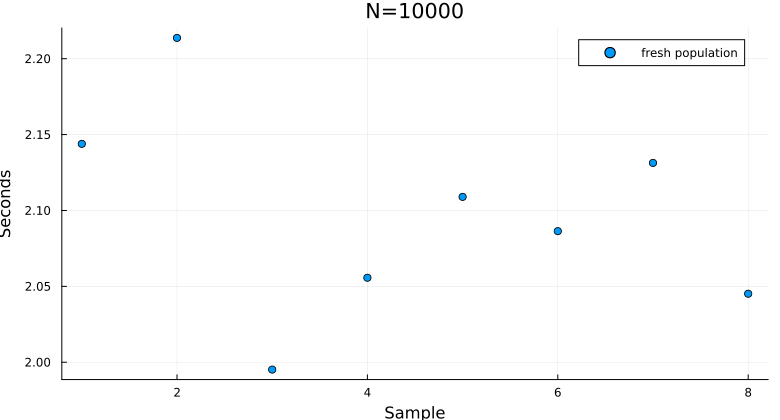

In [2]:
trial = @benchmark finish!(model,40.0) setup=(model=fresh()) evals=1 samples=8 seconds=120
summary = DataFrame(N=[10000],samples=[length(trial)],
    median_seconds=[median(trial).time/1e9],
    min_seconds=[minimum(trial).time/1e9],
    allocated_bytes=[median(trial).memory],
    allocations=[median(trial).allocs])
save_table("benchmark",summary)
display(trial)
display(summary)
figure = scatter(1:length(trial),trial.times/1e9,
    xlabel="Sample",ylabel="Seconds",label="fresh population",title="N=10000")
savefig(figure,imagefile("benchmark"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*